## 통합 과제: CIFAR-10을 활용한 네 가지 모델의 전이 학습, 성능 비교 및 내부 동작 분석


과제 목표
- 모델 학습 및 비교: AlexNet, VGGNet, GoogLeNet, ResNet의 pretrained 모델을 CIFAR-10 데이터셋에 맞게 fine-tuning하여 학습시킵니다.
- 전이 학습 이해: pretrained 가중치 활용과 일부 레이어 freezing 전략을 통해 전이 학습의 효과를 분석합니다.
- Feature Map 시각화: 학습된 모델의 중간 계층 feature map을 추출하고 시각화하여 각 모델이 이미지에서 어떤 특징을 추출하는지 이해합니다.

과제 구성 및 단계
1. 데이터 준비 및 모델 수정
    - CIFAR-10 데이터셋을 불러와 전처리합니다.
    - 각 모델(AlexNet, VGGNet, GoogLeNet, ResNet)의 마지막 분류층을 CIFAR-10(10개 클래스)에 맞게 수정합니다.
    - pretrained 가중치를 로드한 후, 일부 레이어를 freezing하여 학습을 진행합니다.

2. 모델 학습 및 성능 비교
    - 모든 모델에 대해 동일한 하이퍼파라미터(예: 학습률, 배치 크기, 에포크 수)를 사용하여 학습합니다.
    - 학습 과정에서 손실 및 정확도 변화를 기록하고, 최종 테스트 성능을 비교합니다.
    - (선택 사항) 학습 시간, 파라미터 수 등의 효율성도 함께 분석합니다.

3. Feature Map 시각화

    - 학습 완료된 모델에서 특정 중간 계층의 feature map을 추출합니다.
    - PyTorch의 Hook 기능 등을 활용하여, 입력 이미지가 각 계층에서 어떻게 변환되는지 시각화합니다.
    - 모델별로 feature map의 차이를 비교하고, 모델 내부 동작의 차이점을 분석합니다.

# 0. 데이터 전처리
1. CIFAR-10 데이터 각 클래스 별로 10장씩 이미지를 뽑아서 눈으로 직접 확인한다. 

2. CIFAR-10 데이터 이미지들의 차원을 확인해본다. 다른 차원을 갖는 이미지가 있는지 확인한다. (32x32)

3. Resize 비교: CIFAR-10 32x32 원본 이미지와 224x224로 Resize한 이미지를 나란히 비교해본다. 
    - transforms.v2.Resize

5. Normalize 비교: 5장 이미지를 세로로 놓고 비교한다. 각 행에는 원본 이미지와 세 가지의 Normalize 기법을 적용한 사진들, 총 4장을 나열한다. 
    - v2.Normalize
    1. [0.0, 1.0] 스케일링: ToTensor 방식
        - 방법: 원래 0~255인 픽셀 값을 단순히 255로 나눈다.
        - 특징: 가장 기본적이며, 모든 픽셀이 양수 영역에 위치한다.
        - 예시 코드:
        ```python
        v2.Compose([
            v2.ToImage(), 
            v2.ToDtype(torch.float32, scale=True)
        ])
        ```
    2. 전이학습 하려는 데이터셋(SIFAR-10) 맞춤형 정규화
        - 방법: 내가 사용할 CIFAR-10 데이터셋 자체의 평균과 표준편차를 구해서 빼고 나눈다.
        - 특징: CIFAR-10의 평균과 표준편차를 구한다. 내 데이터에 완벽히 최적화된 표준화(Standardization)를 수행한다.
    3. 기존 학습된 데이터(ImageNet) 기준 정규화
        - 방법: 수백만 장의 ImageNet 데이터셋 전체의 평균과 표준편차를 빼고 나눈다. 
            - 이 실험만을 위해 15GB 이미지를 디스크에 담을 수 없으므로 실측값을 사용하는 대신 널리 알려진 값을 믿고 사용한다.
        - 특징: 사전 학습된 가중치가 원래 보던 밝기와 색상 분포대로 이미지를 볼 수 있게 만든다. 즉, 모델이 사전에 학습한 이미지와 픽셀 밝기 분포를 유사하게 만들어서 새로운 이미지더라도 성능이 떨어지지 않도록 보정하는 역할을 하는 것이다. 

6. 데이터 증강 비교: RandomRotation, RandomHorizontalFlip, RandomVerticalFlip: 증강된 이미지를 클래스별로 1장씩 눈으로 확인한다. 
    - v2.RandomHorizontalFlip
    - v2.RandomVerticalFlip
    - v2.RandomRotation: -15~15 degree

6. train/validation/test 데이터셋별로 transforms.Compose() 객체를 만든다. 
    - 224x224 Resize까지는 동일하게 진행하되, Normalization을 축으로 비교 실험을 진행하기 위해 서로 다른 Compose 객체를 만든다. 
        - ToTensor 방식, SIFAR 맞춤형 정규화, ImageNet 기준 정규화 세 개의 객체를 만든다. 
    
    - 데이터증강의 효과를 비교하기 위해 서로 다른 Compose 객체를 만든다. 
    
    - 최종적으로 아래 데이터셋들이 준비되어야 한다. 
        - train: 총 9가지
            - Resize + Normalization{ToTensor | SIFAR-10 | ImageNet} + augmentation{Horizontal + Rotation | Horizontal + Rotation + Vertical | No augmentation}
        - validation: 총 3가지
            - Resize + Normalization{ToTensor | SIFAR-10 | ImageNet}
        - test: 총 3가지
            - Resize + Normalization{ToTensor | SIFAR-10 | ImageNet}
    

In [1]:
# 상수 및 헬퍼 함수

import random
from typing import List, Union
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.datasets import CIFAR10, ImageFolder
import torchvision.transforms.v2 as v2

RANDOM_SEED = 42

# =========================================================================
# [함수 1] 데이터셋 샘플링 시각화 및 차원 검사 범용 함수
# =========================================================================
def inspect_and_visualize_dataset(
    dataset: torch.utils.data.Dataset,
    num_classes: int = 5,
    num_samples_per_class: int = 10,
    seed: int = RANDOM_SEED,  # [변경/추가] 기본값으로 RANDOM_SEED 적용
    title: str = "Dataset Visual Inspection",
):
    """데이터셋에서 N개 클래스를 임의로 뽑아 클래스당 M장씩 시각화하고,
    전체 데이터셋 차원 검사 및 샘플 스펙을 출력하는 범용 함수.

    :param dataset: PyTorch Dataset 객체 (ImageFolder, CIFAR10 등)
    :param num_classes: 임의로 추출할 클래스 개수
    :param num_samples_per_class: 클래스당 추출할 이미지 장수
    :param seed: 난수 고정용 시드값
    :param title: 시각화 그래프 제목
    """
    random.seed(seed)

    # 1. 클래스 이름 매핑
    if hasattr(dataset, "classes") and dataset.classes:
        all_classes = dataset.classes
    else:
        # targets 정보가 있는 경우 역매핑
        unique_targets = list(set(dataset.targets))
        all_classes = [f"Class_{i}" for i in range(len(unique_targets))]

    # 2. 임의의 N개 클래스 무작위 추출
    unique_class_names = sorted(list(set(all_classes)))
    num_classes = min(num_classes, len(unique_class_names))
    selected_classes = random.sample(unique_class_names, num_classes)

    # 3. 클래스별 이미지 수집
    class_samples = {cls_name: [] for cls_name in selected_classes}

    for idx in range(len(dataset)):
        img, label = dataset[idx]
        cls_name = (
            all_classes[label] if isinstance(label, int) else str(label)
        )

        if cls_name in class_samples:
            if len(class_samples[cls_name]) < num_samples_per_class:
                class_samples[cls_name].append(img)

        # 모든 클래스가 지정된 수량을 채우면 루프 조기 종료
        if all(
            len(samples) == num_samples_per_class
            for samples in class_samples.values()
        ):
            break

    # 4. 전체 데이터셋 차원 및 일관성 검사
    total_len = len(dataset)
    unique_shapes = set()

    # CIFAR-10처럼 dataset.data (NumPy Array)가 메모리에 존재하는 경우 즉시 확인
    if hasattr(dataset, "data") and isinstance(dataset.data, np.ndarray):
        full_data_shape = dataset.data.shape  # 예: (50000, 32, 32, 3)
        unique_shapes.add(tuple(full_data_shape[1:]))
        has_different_shapes = False
    else:
        # ImageFolder 등 개별 파일 이미지 dataset인 경우 전체 순회하여 차원 수집
        for idx in range(total_len):
            img_item, _ = dataset[idx]
            if isinstance(img_item, torch.Tensor):
                unique_shapes.add(tuple(img_item.shape))
            else:  # PIL Image 상태
                # (Height, Width, Channels)
                channels = len(img_item.getbands())
                unique_shapes.add(
                    (img_item.size[1], img_item.size[0], channels)
                )

        has_different_shapes = len(unique_shapes) > 1

    # 리포트 출력
    print("=" * 65)
    print(f" [{title} - 차원 및 데이터 스펙 검사]")
    print("=" * 65)
    print(f"• [전체 데이터셋 검사] 총 데이터 수 : {total_len:,}장")

    if hasattr(dataset, "data") and isinstance(dataset.data, np.ndarray):
        print(f"• 전체 데이터 배열 차원 (N, H, W, C) : {full_data_shape}")
        print(
            "• 데이터셋 차원 일관성             : 모든 이미지의 차원이 동일합니다."
        )
    else:
        if has_different_shapes:
            print(
                f"• 데이터셋 차원 일관성             : ⚠️ [서로 다른 차원 존재] 총 {len(unique_shapes)}가지 크기의 이미지가 섞여 있습니다."
            )
            print(
                f"  - 발견된 차원 목록(H, W, C)      : {sorted(list(unique_shapes))[:5]}"
            )
        else:
            single_shape = list(unique_shapes)[0]
            print(
                f"• 데이터셋 차원 일관성             : 모든 이미지의 차원이 동일합니다. (H, W, C) = {single_shape}"
            )

    print("-" * 65)
    print(
        f"• 샘플 추출 조건 : {num_classes}개 클래스 x 클래스당 {num_samples_per_class}장"
    )
    print(f"• 선택된 클래스 목록 : {selected_classes}\n")

    # 5. 선택된 샘플 상세 스펙 출력
    for cls_name in selected_classes:
        sample_img = class_samples[cls_name][0]

        if isinstance(sample_img, torch.Tensor):
            print(f"• 클래스: [{cls_name}] (PyTorch Tensor)")
            print(f"  - Tensor 차원 (C, H, W) : {tuple(sample_img.shape)}")
            print(
                f"  - Data Type             : {sample_img.dtype}, Range: [{sample_img.min():.2f}, {sample_img.max():.2f}]"
            )
        else:  # PIL Image 상태
            img_np = np.array(sample_img)
            tensor_temp = v2.functional.to_image(sample_img)
            print(f"• 클래스: [{cls_name}] (PIL Image)")
            print(
                f"  - PIL 크기 (W x H)       : {sample_img.size} (모드: {sample_img.mode})"
            )
            print(f"  - NumPy 차원 (H, W, C)   : {img_np.shape}")
            print(f"  - PyTorch 차원 (C, H, W) : {tuple(tensor_temp.shape)}")
        print("-" * 65)

    # 6. N x M Grid 시각화
    fig, axes = plt.subplots(
        num_classes,
        num_samples_per_class,
        figsize=(num_samples_per_class * 1.6, num_classes * 1.8),
    )
    fig.suptitle(
        f"{title}\n({num_classes} Classes x {num_samples_per_class} Images)",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )

    # 1차원 배열 예외 처리
    if num_classes == 1 and num_samples_per_class == 1:
        axes = np.array([[axes]])
    elif num_classes == 1:
        axes = np.expand_dims(axes, axis=0)
    elif num_samples_per_class == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, cls_name in enumerate(selected_classes):
        imgs = class_samples[cls_name]
        for col_idx in range(num_samples_per_class):
            ax = axes[row_idx, col_idx]
            img = imgs[col_idx]

            if isinstance(img, torch.Tensor):
                img_show = img.permute(1, 2, 0).cpu().numpy()
                if img_show.max() > 1.0 or img_show.min() < 0.0:
                    img_show = (img_show - img_show.min()) / (
                        img_show.max() - img_show.min() + 1e-8
                    )
                ax.imshow(img_show)
            else:
                ax.imshow(img)

            ax.axis("off")

            if col_idx == 0:
                ax.set_title(
                    f"[{cls_name[:12]}]",
                    fontsize=9,
                    fontweight="bold",
                    loc="left",
                    color="navy",
                )

    plt.tight_layout()
    plt.show()

    return class_samples, selected_classes


# =========================================================================
# [함수 2] 나란히 비교(Resize, Normalize, Augmentation 비교용) 범용 함수
# =========================================================================
def plot_comparison_grid(
    image_matrix: List[List[Union[torch.Tensor, object]]],
    row_labels: List[str],
    col_labels: List[str],
    title: str = "Comparison Grid",
):
    """행(Row)별로 비교 항목을 나란히(Column) 정렬하여 시각화하는 함수.

    :param image_matrix: [N x M] 형태의 2차원 리스트 (PIL Image 또는 Tensor)
    :param row_labels: 각 행의 라벨 (예: 클래스 이름)
    :param col_labels: 각 열의 라벨 (예: [원본 32x32, Resize 224x224, ImageNet])
    """
    n_rows = len(image_matrix)
    n_cols = len(image_matrix[0])

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.8)
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for r in range(n_rows):
        for c in range(n_cols):
            ax = axes[r, c]
            img = image_matrix[r][c]

            if isinstance(img, torch.Tensor):
                img_show = img.permute(1, 2, 0).cpu().numpy()
                if img_show.max() > 1.0 or img_show.min() < 0.0:
                    img_show = (img_show - img_show.min()) / (
                        img_show.max() - img_show.min() + 1e-8
                    )
                ax.imshow(img_show)
            else:
                ax.imshow(img)

            ax.axis("off")

            if r == 0:
                ax.set_title(
                    col_labels[c],
                    fontsize=10,
                    fontweight="bold",
                    pad=6,
                    color="darkgreen",
                )

            if c == 0:
                ax.text(
                    -0.12,
                    0.5,
                    row_labels[r],
                    transform=ax.transAxes,
                    fontsize=10,
                    fontweight="bold",
                    va="center",
                    ha="right",
                    color="navy",
                )

    plt.tight_layout()
    plt.show()


 [CIFAR-10 Dataset Samples Inspection - 차원 및 데이터 스펙 검사]
• [전체 데이터셋 검사] 총 데이터 수 : 50,000장
• 전체 데이터 배열 차원 (N, H, W, C) : (50000, 32, 32, 3)
• 데이터셋 차원 일관성             : 모든 이미지의 차원이 동일합니다.
-----------------------------------------------------------------
• 샘플 추출 조건 : 5개 클래스 x 클래스당 10장
• 선택된 클래스 목록 : ['automobile', 'airplane', 'deer', 'truck', 'frog']

• 클래스: [automobile] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
-----------------------------------------------------------------
• 클래스: [airplane] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
-----------------------------------------------------------------
• 클래스: [deer] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
----------------------------------------------------------

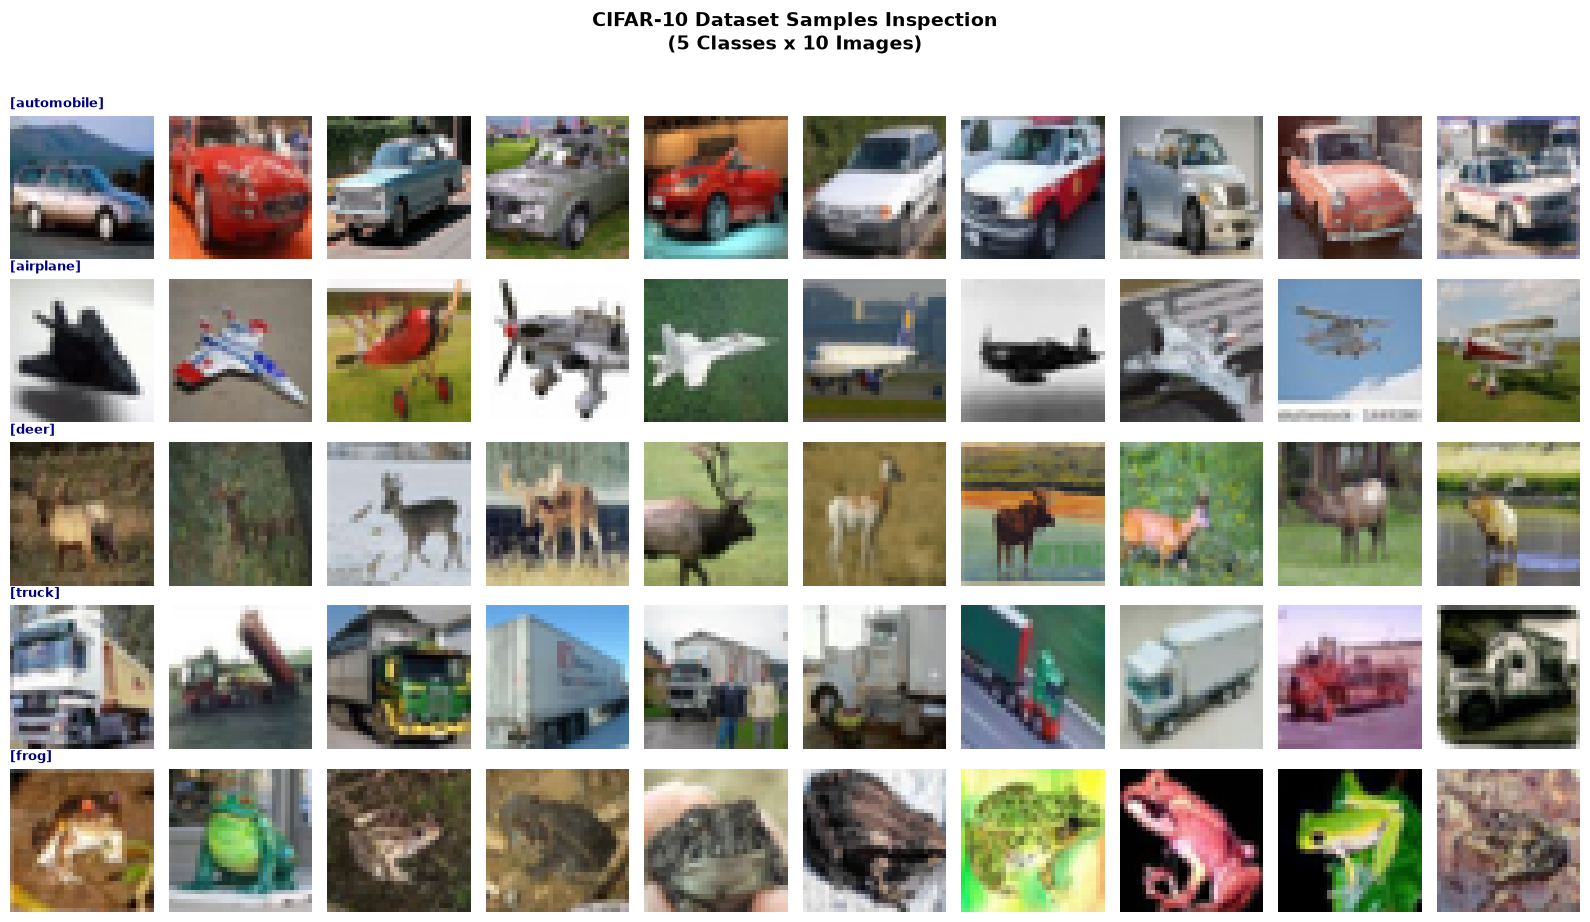

 [CIFAR-10 Test Dataset Inspection - 차원 및 데이터 스펙 검사]
• [전체 데이터셋 검사] 총 데이터 수 : 10,000장
• 전체 데이터 배열 차원 (N, H, W, C) : (10000, 32, 32, 3)
• 데이터셋 차원 일관성             : 모든 이미지의 차원이 동일합니다.
-----------------------------------------------------------------
• 샘플 추출 조건 : 5개 클래스 x 클래스당 10장
• 선택된 클래스 목록 : ['automobile', 'airplane', 'deer', 'truck', 'frog']

• 클래스: [automobile] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
-----------------------------------------------------------------
• 클래스: [airplane] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
-----------------------------------------------------------------
• 클래스: [deer] (PIL Image)
  - PIL 크기 (W x H)       : (32, 32) (모드: RGB)
  - NumPy 차원 (H, W, C)   : (32, 32, 3)
  - PyTorch 차원 (C, H, W) : (3, 32, 32)
-------------------------------------------------------------

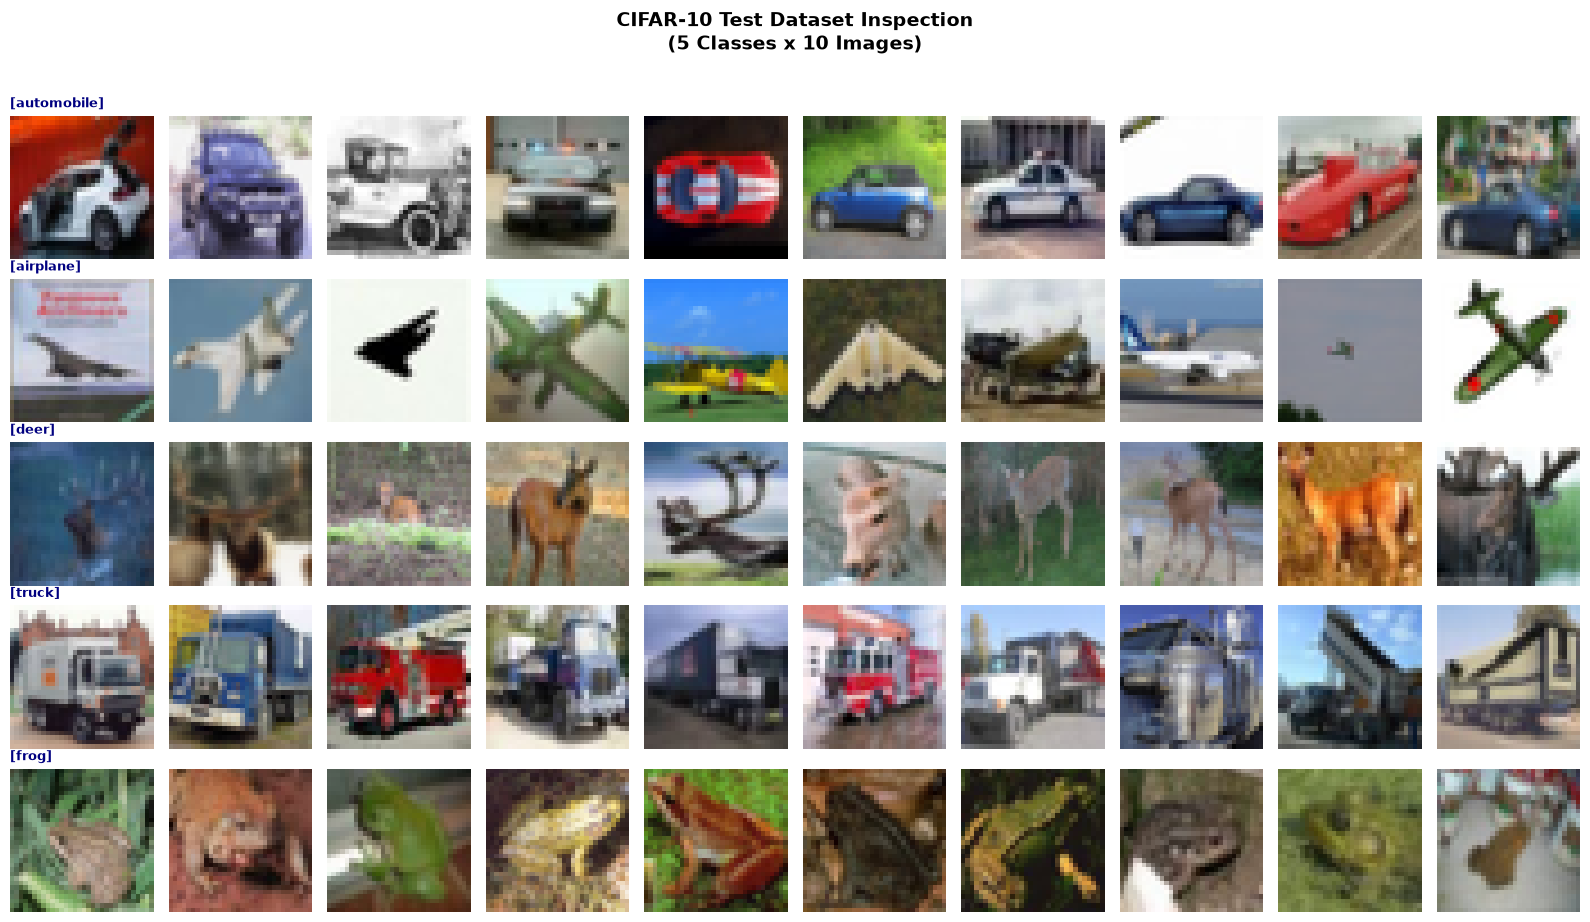

In [2]:
# CIFAR-10 데이터 클래스 5개를 임의로 뽑아 10장씩 이미지를 뽑아서 눈으로 직접 확인한다. 차원도 함께 확인한다. 

import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision.datasets import CIFAR10

# CIFAR-10 원본 데이터셋 로드 (전처리 전 PIL 이미지 상태)
cifar10_train_dataset = CIFAR10(root="./data", train=True, download=True)
cifar10_test_dataset = CIFAR10(root="./data", train=False, download=True)

all_classes = cifar10_train_dataset.classes

# Train 데이터셋 무결성 검증 및 차원 확인
cifar10_samples, cifar10_classes = inspect_and_visualize_dataset(
    dataset=cifar10_train_dataset,
    num_classes=5,  # 임의 추출할 클래스 수
    num_samples_per_class=10,  # 클래스당 이미지 장수
    seed=RANDOM_SEED,  # 난수 고정용 시드값
    title="CIFAR-10 Dataset Samples Inspection",
)

# Test 데이터셋 무결성 및 차원 확인
test_samples, test_classes = inspect_and_visualize_dataset(
    dataset=cifar10_test_dataset,
    num_classes=5,
    num_samples_per_class=10,
    seed=RANDOM_SEED,  # Train과 동일한 시드를 주면 클래스 선택 기준이 동일해집니다.
    title="CIFAR-10 Test Dataset Inspection",
)

In [ ]:
# Resize 비교: CIFAR-10 32x32 원본 이미지와 224x224로 Resize한 이미지를 나란히 놓고 비교한다. 

In [ ]:
# Normalize 비교: 5x4로 이미지를 비교한다. 각 행에는 원본 이미지 한 장과 세 가지의 Normalize 기법을 적용한 사진들, 총 4장을 나열한다.

In [ ]:
# 데이터 증강 비교: RandomRotation, RandomHorizontalFlip, RandomVerticalFlip: 증강된 이미지를 클래스별로 1장씩 눈으로 확인한다. 

In [ ]:
# train/validation/test 데이터셋 분할. train: 9가지, val/test: 3가지 데이터셋이 준비된다.

# 1. 베이스라인 잡기

1. AlexNet, VGGNet, GoogLeNet, ResNet 네 모델의 가중치를 설정하지 않은 상태(weights=None)에서 마지막 FC 레이어의 출력층만 10개로 맞추고 CIFAR-10 데이터로 처음부터 끝까지 학습시킨다. 
    - **목표**: From the Scratch 학습의 베이스라인을 잡는다. 이 베이스라인으로 "ImageNet에서 미리 배워온 지식이 있을 때(전이학습)가 맨땅에 헤딩할 때(From the Scratch)보다 학습 속도가 얼마나 빠르고 최종 성능이 얼마나 높은지"를 아주 명확하게 수치로 비교할 수 있다.
    - 베이스라인 모델 훈련에 사용하는 데이터 전처리는 가장 정석대로 한다. 
        - **크기 조정 (Resize 224x224)**: 모델의 파라미터 수와 연산 구조를 전이학습 모델과 완벽하게 동일하게 통제하기 위해 반드시 필요하다. 
        - **정규화 (CIFAR-10 Normalization)**: 백지상태에서 CIFAR-10 데이터만 보고 학습하므로, 모델에게 해당 데이터셋 자체의 통계값을 제공하여 최적화(Standardization)하는 것이 가장 정확하다.
        - **데이터 증강 (Horizontal Flip + Rotation)**: 처음부터 학습하는 모델은 사전 학습된 모델보다 특징을 추출하는 방법을 배우는 데 훨씬 더 많은 데이터를 필요로 하며, 과적합(Overfitting)에 매우 취약하다. 따라서 기본적인 공간 변형 증강을 반드시 넣어주어야 베이스라인 모델이 최대한의 제 성능을 발휘할 수 있다. (위험 부담이 있는 Vertical Flip은 제외한다.)
    - 학습에 소요된 리소스(시간, 에폭별 loss 감소 시계열, 파라미터 수)를 기록한다. 

2. 학습 완료된 네 모델에 대해서 임의의 이미지를 하나 입력으로 넣는다. PyTorch의 Hook 기능을 활용하여, 입력 이미지가 각 계층에서 어떻게 변하는 지 시각화한다. 
    - 목표1: 모델이 이미지를 해석하는 과정을 시각적으로 확인한다. 
    - 목표2: Fine tune from the scratch 모델과 추후 진행하는 전이학습 모델 간의 이미지를 어떻게 해석을 비교하기 위한 베이스라인으로 사용한다. 

# 2. 모델 수정

1. AlexNet, VGGNet, GoogLeNet, ResNet의 pretrained 모델을 불러와 마지막 분류층을 CIFAR-10(10개 클래스)에 맞게 수정한다.
2. FC 층만 놔두고 다른 레이어는 freezing한다. 

# 3. 모델 학습

모든 전처리/모델 조합에 대해 동일한 하이퍼파라미터(예: 학습률, 배치 크기, 에포크 수)를 사용하여 학습한다.
- 학습 과정에서 손실 및 정확도 변화를 기록한다.
- 학습 시간, 파라미터 수 등의 효율성도 함께 분석한다.

# 4. 성능 비교

1. 전처리 데이터 성능 비교 -> 최고의 데이터 전처리 방식을 선정한다. 
    - AlexNet, VGGNet, GoogLeNet, ResNet 네 모델 각각에 대해서 9가지 경우의 데이터 전처리 성능을 비교한다. 
    - validation 점수를 활용해 가장 우수한 성능을 보인 데이터 전처리 방식을 하나 선정한다. 

2. BaseLine 네 가지 모델(fine tune from the scratch)와 전이학습 네 가지 모델(with best pre-processed dataset)의 성능을 비교한다. 
    - validation 점수를 기준으로 비교한다. 
    - 최종 성능과 학습 속도(Epoch당 Loss 감소율)을 비교한다. 
        - 주의: 학습해야 할 파라미터 수가 수백 배 차이 나기 때문에, 전이학습 모델의 1 Epoch 학습 속도가 베이스라인보다 압도적으로 빠를 수밖에 없다. 따라서 '학습 속도'를 비교할 때, 단순히 "전이학습이 시간이 적게 걸린다"가 아니라 "학습할 파라미터가 압도적으로 적은데도(혹은 미세조정의 경우 초기값이 좋아서) 수렴하는 속도(Loss 감소율)가 얼마나 더 가파른지"에 초점을 맞춰 분석한다.
    - Baseline 네 가지 모델과 전이학습 네 가지 모델에 대해 클래스별 5개 이미지를 뽑아서 눈으로 비교한다. 

3. 최종 test: 최종 모델의 점수를 확인한다. 
    - BaseLine test 점수
    - AlexNet(trained with Best pre-processed data set)
    - VGGNet(trained with Best pre-processed data set)
    - GoogLeNet(trained with Best pre-processed data set)
    - ResNet(trained with Best pre-processed data set)

# 5. feature map 시각화

1. 학습 완료된 네 모델에 대해서 0. Baseline에서 넣은 이미지를 하나 입력으로 넣는다. PyTorch의 Hook 기능을 활용하여 feature map을 추출해 입력 이미지가 각 계층에서 어떻게 변하는 지 시각화한다. 
    - 목표 : 0. Baseline에서 확보한 fine tune from the scratch 모델과 전이학습 모델의 이미지 해석 방식의 차이를 시각적으로 확인한다. 